<a href="https://colab.research.google.com/github/Rukaya-lab/Engineering-ML-Features-for-MOF-CO2-Adsorption/blob/main/II_Crafted_MOF_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("/content/CRAFTED_geo.csv")
data

,FrameworkName,D_is,D_fs,D_isfs,ASA_m^2/cm^3,ASA_m^2/g,Density,AV_Volume_fraction,AV_cm^3/g,Unitcell_volume,NASA_m^2/cm^3,NASA_m^2/g,NAV_Volume_fraction,NAV_cm^3/g,n_pockets,uptake_DDEC_298K_10bar,uptake_DDEC_298K_0.1bar,uptake_DDEC_298K_0.001bar,uptake_DDEC_298K_1bar_N2
0,ABUWOJ,5.07969,4.03039,4.98773,2287.89,1975.170,1.158330,0.100160,0.086470,4518.160,0.0000,0.0000,0.000000,0.000000,0,7.786347,3.377670,0.077836,0.455594
1,ACOLIP,4.91034,3.57647,4.78103,1810.94,1725.550,1.049490,0.062495,0.059548,1527.860,0.0000,0.0000,0.000000,0.000000,0,7.079651,1.262269,0.015418,0.352806
2,ACUBAB,6.47918,4.30437,6.24909,1472.91,637.778,2.309440,0.095670,0.041426,1622.680,0.0000,0.0000,0.000000,0.000000,0,2.677382,0.995901,0.012419,0.293798
3,AFITIT,7.35330,5.37116,7.35330,1673.22,1645.520,1.016830,0.131930,0.129746,4269.850,11.7557,11.5611,0.000135,0.000133,1,5.971295,0.445196,0.005392,0.247263
4,AFOQUI,4.25157,3.00568,4.24901,845.47,521.603,1.620910,0.019075,0.011768,2076.400,0.0000,0.0000,0.000000,0.000000,0,2.283888,0.598248,0.008047,0.073313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,Zn-DOBDC,11.71732,10.90932,11.71732,1734.15,1422.060,1.219460,0.347595,0.285039,1327.160,0.0000,0.0000,0.000000,0.000000,0,9.359285,0.346808,0.003315,0.243095
722,ZNGLUD,3.19455,2.66271,3.17912,0.00,0.000,1.654040,0.000000,0.000000,845.325,252.1960,152.4730,0.001830,0.001106,4,2.944307,0.222786,0.002326,0.001349
723,ZNGLUD01,3.16473,2.59565,3.12072,0.00,0.000,1.685060,0.000000,0.000000,829.761,203.4450,120.7340,0.001390,0.000825,4,1.538036,0.061411,0.000534,0.000627
724,ZnHBDC,9.54884,7.69489,9.54884,2043.47,2357.610,0.866753,0.283005,0.326512,2134.760,0.0000,0.0000,0.000000,0.000000,0,11.937390,0.546255,0.006009,0.285684


**Data description**

- D_is: largest cavity diameter (extracted by Delaunay triangulation method with a grid spacing of 0.1 Å)
- D_fs: pore limiting diameter (largest free sphere) (extracted by Delaunay triangulation method)
- D_isfs: largest included sphere along a free path
- ASA_m3/cm3: volumetric accessible area
- ASA_m3/g: gravimetric accessible area
- Density: Crystal density
- AV_volume_fraction: accessible volume fraction
- AV_cm3/g: accessible volume
- Unit_cell_volume:
- NASA/CM3: volumetric non-accessible area
- NASA/g: gravimetric non-accessible area
- NAV_volume_fraction: non accessible volume fraction
- NAV_cm3/g: non accessible volume
- n_pockets: number of pockets

**Predictions**

- uptake_DDEC_298K_10bar
- uptake_DDEC_298K_0.1bar
- uptake_DDEC_298K_0.001bar
- uptake_DDEC_298K_1bar

In [ ]:
#data['host_interaction_10'] = data['uptake_DDEC_298K_10bar']/10
#data['host_interaction_0.1'] = data['uptake_DDEC_298K_0.1bar']/0.1
data['host_interaction_0.001'] = data['uptake_DDEC_298K_0.001bar']/0.001

# Insert the new columns at the specified indices
#data.insert(loc=15, column='host_interactions_10', value=data['host_interaction_10'])
#data.insert(loc=16, column='host_interactions_0.1', value=data['host_interaction_0.1'])
data.insert(loc=15, column='host_interactions_0.001', value=data['host_interaction_0.001'])

# Drop the intermediate columns if needed
data.drop([ 'host_interaction_0.001'], axis=1, inplace=True)

data.head()

,FrameworkName,D_is,D_fs,D_isfs,ASA_m^2/cm^3,ASA_m^2/g,Density,AV_Volume_fraction,AV_cm^3/g,Unitcell_volume,NASA_m^2/cm^3,NASA_m^2/g,NAV_Volume_fraction,NAV_cm^3/g,n_pockets,host_interactions_0.001,uptake_DDEC_298K_10bar,uptake_DDEC_298K_0.1bar,uptake_DDEC_298K_0.001bar,uptake_DDEC_298K_1bar_N2
0,ABUWOJ,5.07969,4.03039,4.98773,2287.89,1975.170,1.15833,0.100160,0.086470,4518.16,0.0000,0.0000,0.000000,0.000000,0,77.8360,7.786347,3.377670,0.077836,0.455594
1,ACOLIP,4.91034,3.57647,4.78103,1810.94,1725.550,1.04949,0.062495,0.059548,1527.86,0.0000,0.0000,0.000000,0.000000,0,15.4184,7.079651,1.262269,0.015418,0.352806
2,ACUBAB,6.47918,4.30437,6.24909,1472.91,637.778,2.30944,0.095670,0.041426,1622.68,0.0000,0.0000,0.000000,0.000000,0,12.4191,2.677382,0.995901,0.012419,0.293798
3,AFITIT,7.35330,5.37116,7.35330,1673.22,1645.520,1.01683,0.131930,0.129746,4269.85,11.7557,11.5611,0.000135,0.000133,1,5.3925,5.971295,0.445196,0.005392,0.247263
4,AFOQUI,4.25157,3.00568,4.24901,845.47,521.603,1.62091,0.019075,0.011768,2076.40,0.0000,0.0000,0.000000,0.000000,0,8.0469,2.283888,0.598248,0.008047,0.073313


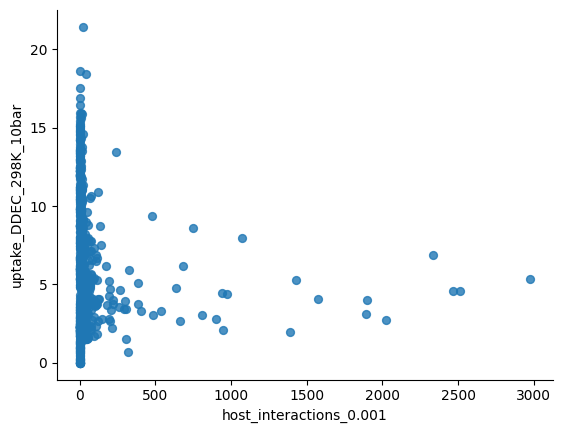

In [ ]:
# @title host_interactions_10 vs uptake_DDEC_298K_10bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='host_interactions_0.001', y='uptake_DDEC_298K_10bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


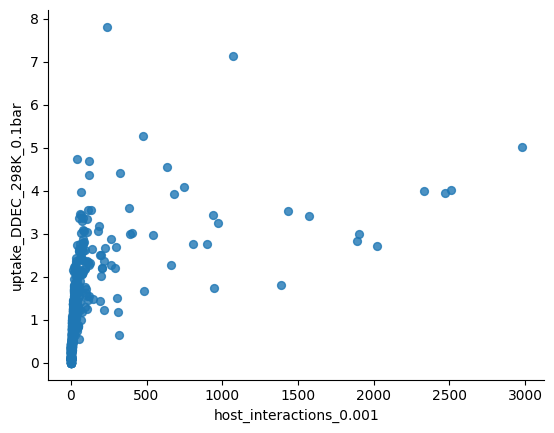

In [ ]:
# @title host_interactions_0.1 vs uptake_DDEC_298K_0.1bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='host_interactions_0.001', y='uptake_DDEC_298K_0.1bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


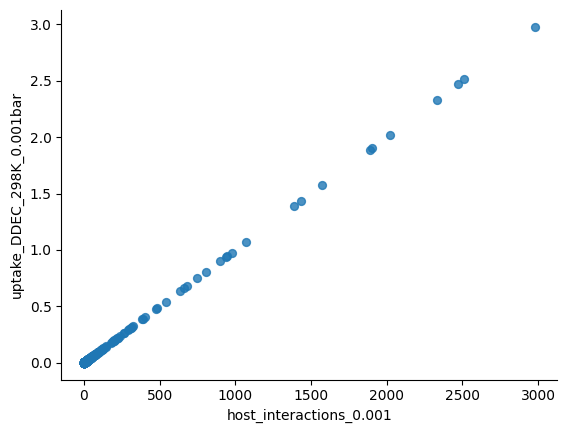

In [ ]:
# @title host_interaction_0.001 vs uptake_DDEC_298K_0.001bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='host_interactions_0.001', y='uptake_DDEC_298K_0.001bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

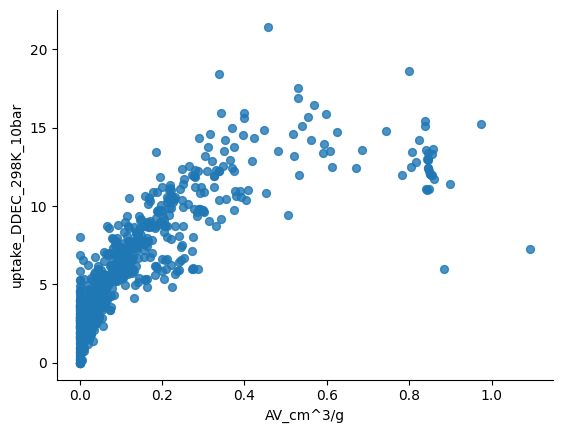

In [ ]:
# @title AV_cm3/g vs uptake_DDEC_298K_10bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='AV_cm^3/g', y='uptake_DDEC_298K_10bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

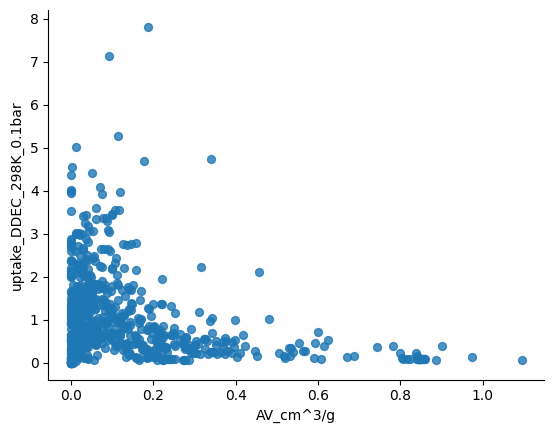

In [ ]:
# @title AV_cm3/g vs uptake_DDEC_298K_0.1bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='AV_cm^3/g', y='uptake_DDEC_298K_0.1bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

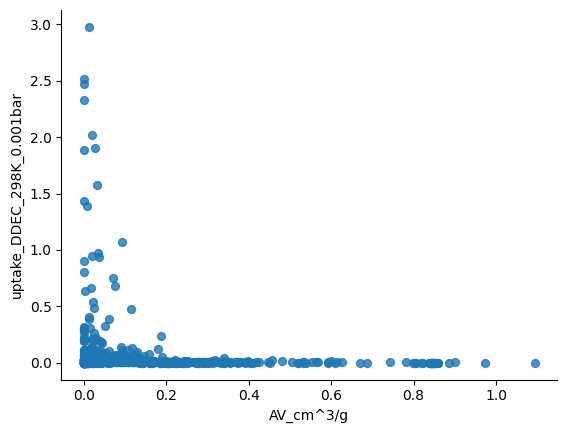

In [ ]:
# @title AV_cm3/g vs uptake_DDEC_298K_0.001bar

from matplotlib import pyplot as plt
data.plot(kind='scatter', x='AV_cm^3/g', y='uptake_DDEC_298K_0.001bar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
data.describe()

,D_is,D_fs,D_isfs,ASA_m^2/cm^3,ASA_m^2/g,Density,AV_Volume_fraction,AV_cm^3/g,Unitcell_volume,NASA_m^2/cm^3,...,NAV_Volume_fraction,NAV_cm^3/g,n_pockets,host_interactions_10,host_interactions_0.1,host_interactions_0.001,uptake_DDEC_298K_10bar,uptake_DDEC_298K_0.1bar,uptake_DDEC_298K_0.001bar,uptake_DDEC_298K_1bar_N2
count,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,...,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000
mean,6.438434,4.812277,6.394658,1385.598348,1361.100721,1.259891,0.123516,0.140303,2621.739722,82.234752,...,0.002875,0.002140,1.020661,0.594824,10.184683,67.264512,5.948237,1.018468,0.067265,0.319700
std,2.811253,2.280766,2.817403,795.687395,1082.135009,0.368627,0.127091,0.197026,1443.241617,251.189697,...,0.013159,0.010652,2.781389,0.390957,9.849911,266.385719,3.909570,0.984991,0.266386,0.251156
min,2.024680,1.013180,2.024680,0.000000,0.000000,0.508540,0.000000,0.000000,271.189000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.608815,3.317122,4.547935,867.555750,588.362750,0.990880,0.028300,0.019853,1515.665000,0.000000,...,0.000000,0.000000,0.000000,0.272023,3.466870,3.597800,2.720230,0.346687,0.003598,0.186004
50%,5.522295,3.977440,5.460680,1400.225000,1105.090000,1.224995,0.073320,0.059498,2279.960000,0.000000,...,0.000000,0.000000,0.000000,0.518633,6.963361,8.781200,5.186333,0.696336,0.008781,0.281476
75%,7.393965,5.730215,7.378982,2041.852500,1974.165000,1.494378,0.191741,0.186856,3547.270000,0.000000,...,0.000000,0.000000,0.000000,0.857667,13.791516,28.111650,8.576665,1.379152,0.028112,0.411388
max,23.905910,23.682860,23.905910,3241.840000,5136.510000,2.898140,0.568230,1.094250,7037.110000,1797.210000,...,0.248150,0.202302,22.000000,2.143268,78.174324,2978.072400,21.432679,7.817432,2.978072,2.284378


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FrameworkName              726 non-null    object 
 1   D_is                       726 non-null    float64
 2   D_fs                       726 non-null    float64
 3   D_isfs                     726 non-null    float64
 4   ASA_m^2/cm^3               726 non-null    float64
 5   ASA_m^2/g                  726 non-null    float64
 6   Density                    726 non-null    float64
 7   AV_Volume_fraction         726 non-null    float64
 8   AV_cm^3/g                  726 non-null    float64
 9   Unitcell_volume            726 non-null    float64
 10  NASA_m^2/cm^3              726 non-null    float64
 11  NASA_m^2/g                 726 non-null    float64
 12  NAV_Volume_fraction        726 non-null    float64
 13  NAV_cm^3/g                 726 non-null    float64

In [ ]:
def data_features(data):
  df = data.iloc[:, 1:16]
  df_n = np.array(df)
  return df_n

def data_targets(data, target):
  df = data.iloc[:, target]
  df_t = np.array(df)
  return df_t

def target_names(data, target):
   names = data.columns[target]
   return 'Prediction:', names

In [ ]:
for i in range(16,19):
  print(target_names(data, i))

('Prediction:', 'uptake_DDEC_298K_10bar')
('Prediction:', 'uptake_DDEC_298K_0.1bar')
('Prediction:', 'uptake_DDEC_298K_0.001bar')


In [ ]:
x= data_features(data)
x.shape

(726, 17)

All features train

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:


def train(model, data, target):
  target_name = target_names(data, target)
  features = data_features(data)
  target = data_targets(data, target)
  model = model
  #split data
  X_train, X_test, y_train, y_test= train_test_split(features, target, train_size= 0.8, random_state= 42)

  #fit model
  model.fit(X_train, y_train)
  #prediction
  y_pred = model.predict(X_test)

  r_score = r2_score(y_test, y_pred)

  #prediction

  print(target_name)
  #result
  print('R_squared: ', r_score)

  plt.scatter(y_test, y_pred)
  plt.title('Predictions vs actual result')
  plt.xlabel('GCMC CO2 uptake[mol/kg]')
  plt.ylabel('predicted CO2 uptake[mol/kg]')
  plt.show()

('Prediction:', 'uptake_DDEC_298K_10bar')
R_squared:  0.9035869313060371


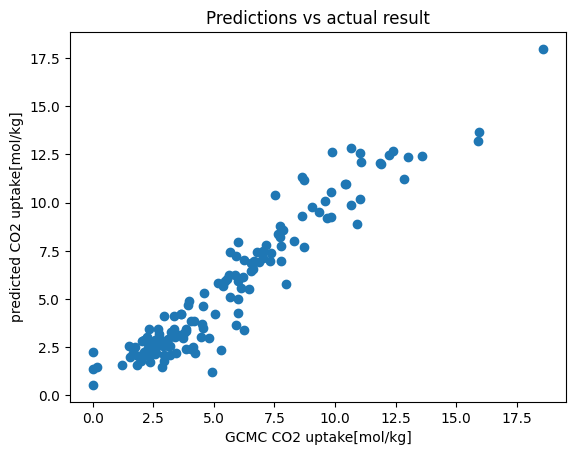

('Prediction:', 'uptake_DDEC_298K_0.1bar')
R_squared:  0.34027834704141124


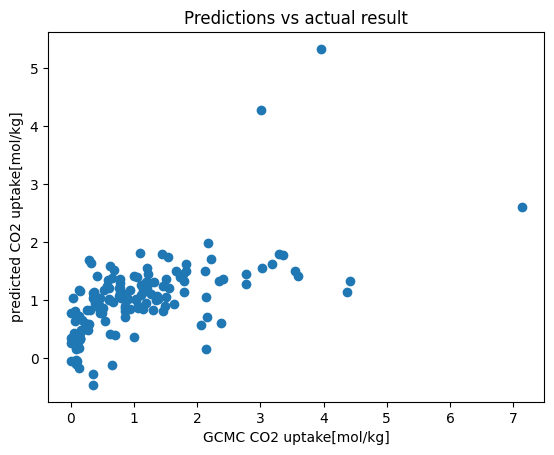

('Prediction:', 'uptake_DDEC_298K_0.001bar')
R_squared:  1.0


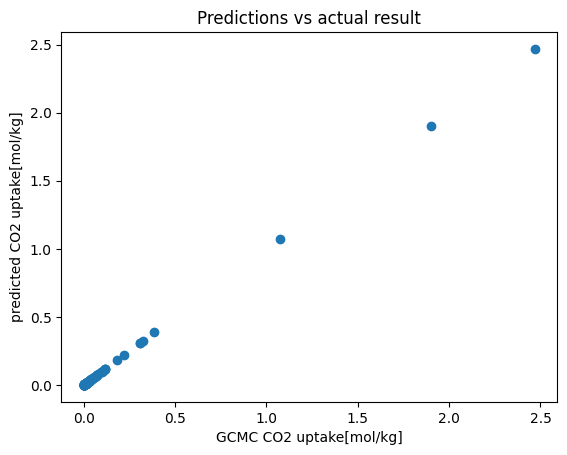

In [ ]:
model = LinearRegression()
for i in range(16,19):
  train(model, data, i)

('Prediction:', 'uptake_DDEC_298K_10bar')
R_squared:  0.9256039491712862


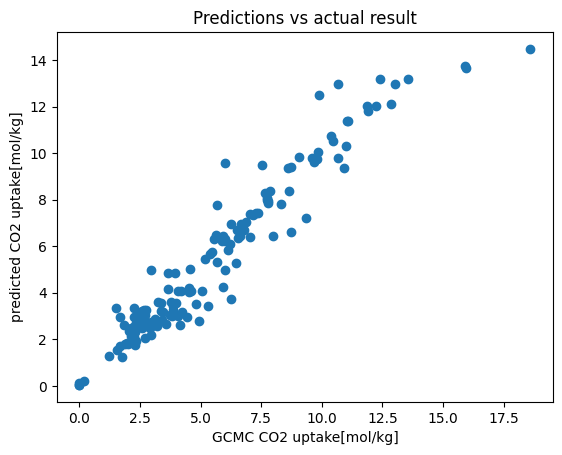

('Prediction:', 'uptake_DDEC_298K_0.1bar')
R_squared:  0.7658030391705145


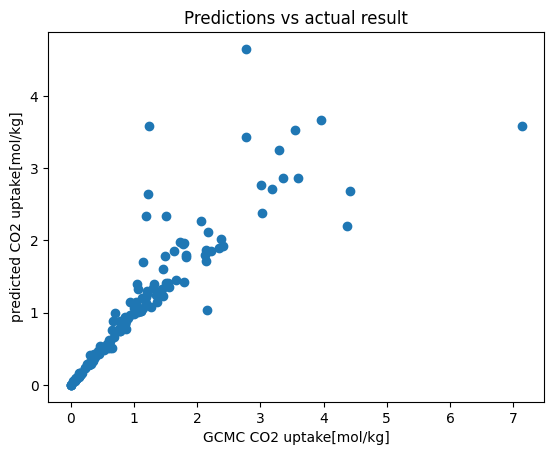

('Prediction:', 'uptake_DDEC_298K_0.001bar')
R_squared:  0.9950365883809239


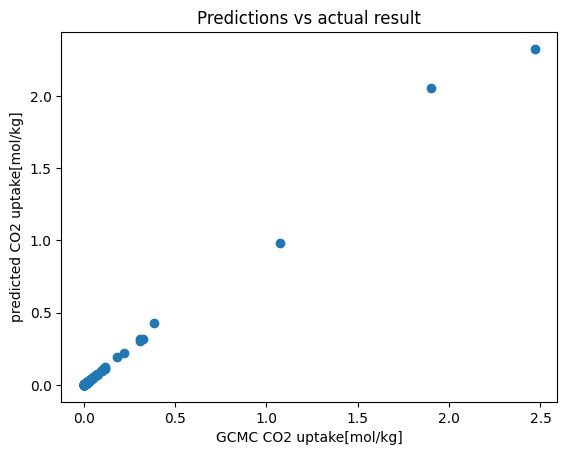

In [ ]:
model = RandomForestRegressor(n_estimators=100)
for i in range(16,19):
  train(model, data, i)

In [ ]:
def train_with_scale(model, data, target):
  target_name = target_names(data, target)
  features = data_features(data)
  target = data_targets(data, target)
  model = model
  #split data
  X_train, X_test, y_train, y_test= train_test_split(features, target, train_size= 0.8, random_state= 42)

   #scale
  scaler = StandardScaler()
  x_train = scaler.fit_transform(X_train)
  x_test = scaler.transform(X_test)

  #fit model
  model.fit(x_train, y_train)
  #prediction
  y_pred = model.predict(x_test)

  r_score = r2_score(y_test, y_pred)

  #prediction

  print(target_name)
  #result
  print('R_squared: ', r_score)

  plt.scatter(y_test, y_pred)
  plt.title('Predictions vs actual result')
  plt.xlabel('GCMC CO2 uptake[mol/kg]')
  plt.ylabel('predicted CO2 uptake[mol/kg]')
  plt.show()

('Prediction:', 'uptake_DDEC_298K_10bar')
R_squared:  0.903586931306001


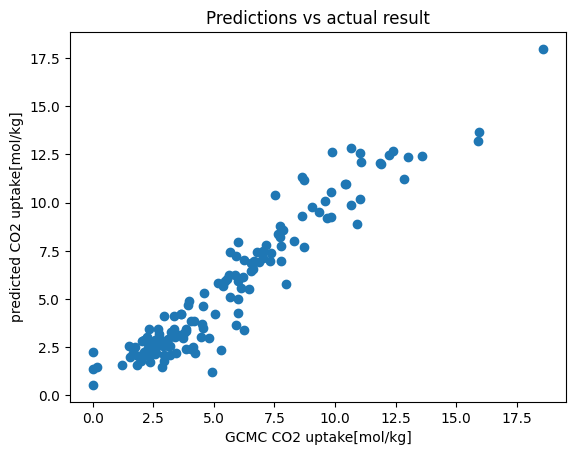

('Prediction:', 'uptake_DDEC_298K_0.1bar')
R_squared:  0.34027834704146165


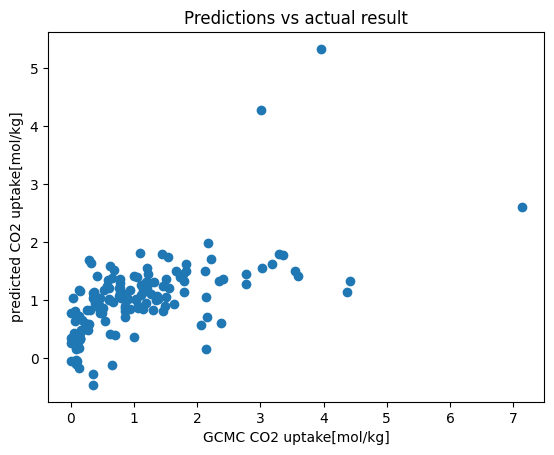

('Prediction:', 'uptake_DDEC_298K_0.001bar')
R_squared:  1.0


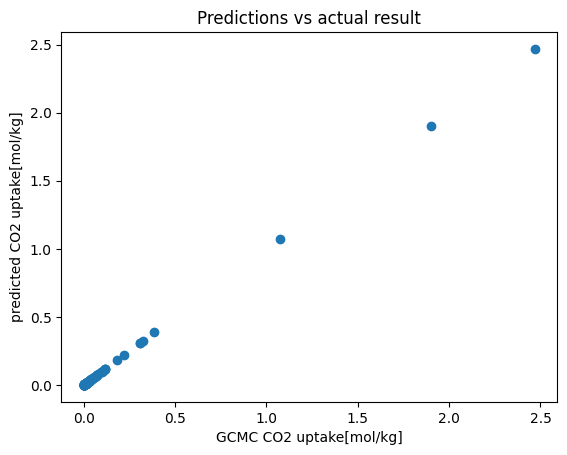

In [ ]:
model = LinearRegression()
for i in range(16,19):
  train_with_scale(model, data, i)

Transforming

In [ ]:
!pip install Boruta --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.7 MB/s eta 0:00:00


In [ ]:
#!pip install --upgrade numpy==1.23.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 28.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chex 0.1.85 requires numpy>=1.24.1, but you have numpy 1.23.1 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 1.23.1 which is incompatible.


In [ ]:
#pip list

In [ ]:
from boruta import BorutaPy

In [ ]:
def train_refeatured(model, data, target):
  target_name = target_names(data, target)
  features = data_features(data)
  target = data_targets(data, target)
  model = model
  #split data
  X_train, X_test, y_train, y_test= train_test_split(features, target, train_size= 0.8, random_state= 42)


  #fit model feature selector
  boruta_selector = BorutaPy(model, n_estimators= 1000, verbose=2, random_state=42, max_iter=10)   # initialize the boruta selector

  boruta_selector.fit(X_train, y_train)

  print("Selected Features: ", boruta_selector.support_)    # check selected features
  print("Ranking: ", boruta_selector.ranking_)               # check ranking of features
  print("No. of significant features: ", boruta_selector.n_features_)


  #train with important features
  ## creating a new subse of data with selected features

  X_important_train = boruta_selector.transform(np.array(X_train))
  X_important_test = boruta_selector.transform(np.array(X_test))
  #prediction
  if boruta_selector.n_features_ == 0:
    print('Training stopped due to No features')
  else:
    model.fit(X_important_train, y_train)

    y_pred_imp = model.predict(X_important_test)

    r_score = r2_score(y_test, y_pred_imp)

    #prediction

    print(target_name)
    #result
    print('R_squared: ', r_score)

    plt.scatter(y_test, y_pred_imp)
    plt.title('Predictions vs actual result')
    plt.xlabel('GCMC CO2 uptake[mol/kg]')
    plt.ylabel('predicted CO2 uptake[mol/kg]')
    plt.show()

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	6
Tentative: 	3
Rejected: 	6
Iteration: 	9 / 10
Confirmed: 	6
Tentative: 	3
Rejected: 	6


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	6
Tentative: 	3
Rejected: 	6
Selected Features:  [False False False  True  True  True  True  True False False False False
 False False  True]
Ranking:  [4 2 5 1 1 1 1 1 2 3 2 8 6 7 1]
No. of significant features:  6
('Prediction:', 'uptake_DDEC_298K_10bar')
R_squared:  0.9309454381192765


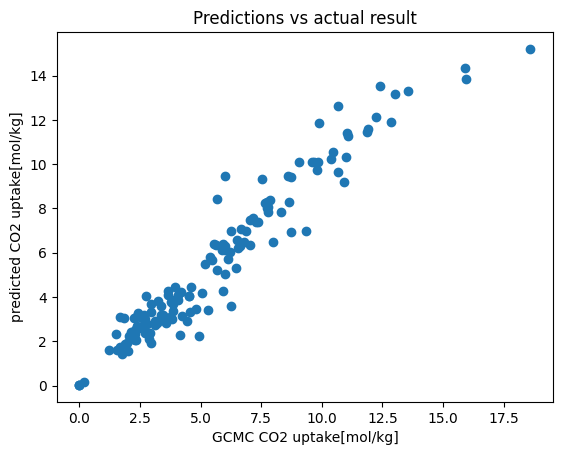

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	6
Tentative: 	4
Rejected: 	5
Iteration: 	9 / 10
Confirmed: 	6
Tentative: 	4
Rejected: 	5


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	6
Tentative: 	0
Rejected: 	5
Selected Features:  [False False False  True  True  True  True  True False False False False
 False False  True]
Ranking:  [ 5  3  4  1  1  1  1  1  2  8  7 10  9  6  1]
No. of significant features:  6
('Prediction:', 'uptake_DDEC_298K_0.1bar')
R_squared:  0.7620433239192596


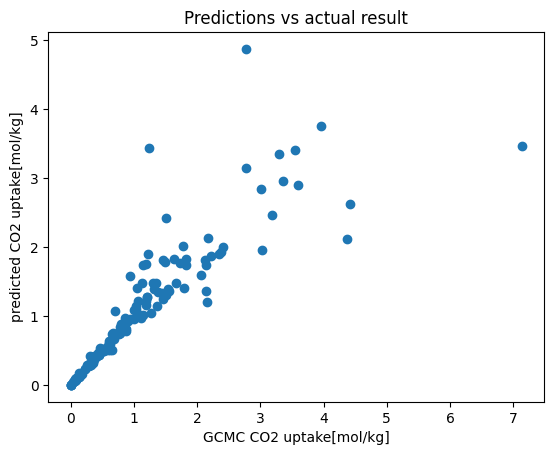

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	15
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	0
Tentative: 	1
Rejected: 	14
Iteration: 	9 / 10
Confirmed: 	1
Tentative: 	0
Rejected: 	14


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	1
Tentative: 	0
Rejected: 	14
Selected Features:  [False False False False False False False False False False False False
 False False  True]
Ranking:  [ 6  7  3 12  5  2 10 14  4  9  8 15 12 12  1]
No. of significant features:  1
('Prediction:', 'uptake_DDEC_298K_0.001bar')
R_squared:  0.9987679611890009


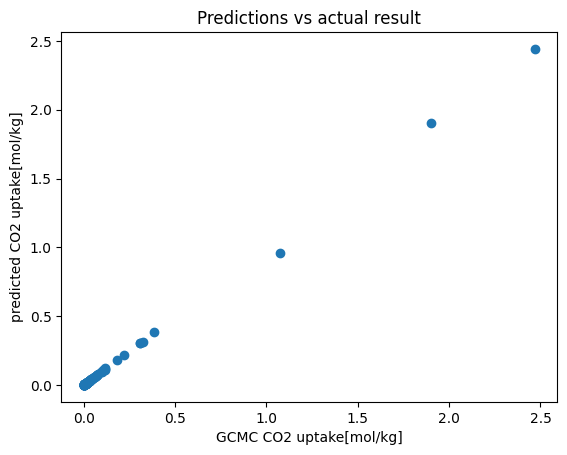

In [ ]:
model = RandomForestRegressor(n_estimators=100)
for i in range(16,19):
  train_refeatured(model, data, i)